In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

era5 = xr.open_zarr(
    "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3",
    storage_options={"token": "anon"}
)

In [2]:
[v for v in era5.data_vars if "temperature" in v.lower()]

['2m_dewpoint_temperature',
 '2m_temperature',
 'ice_temperature_layer_1',
 'ice_temperature_layer_2',
 'ice_temperature_layer_3',
 'ice_temperature_layer_4',
 'lake_bottom_temperature',
 'lake_ice_temperature',
 'lake_mix_layer_temperature',
 'lake_total_layer_temperature',
 'maximum_2m_temperature_since_previous_post_processing',
 'minimum_2m_temperature_since_previous_post_processing',
 'sea_surface_temperature',
 'skin_temperature',
 'soil_temperature_level_1',
 'soil_temperature_level_2',
 'soil_temperature_level_3',
 'soil_temperature_level_4',
 'temperature',
 'temperature_of_snow_layer',
 'vertical_integral_of_temperature']

In [3]:
t2m = era5["2m_temperature"]

india = t2m.sel(
    latitude=slice(40,5),
    longitude=slice(65,100)
)

Text(0.5, 1.0, 'India Mean 2m Temperature')

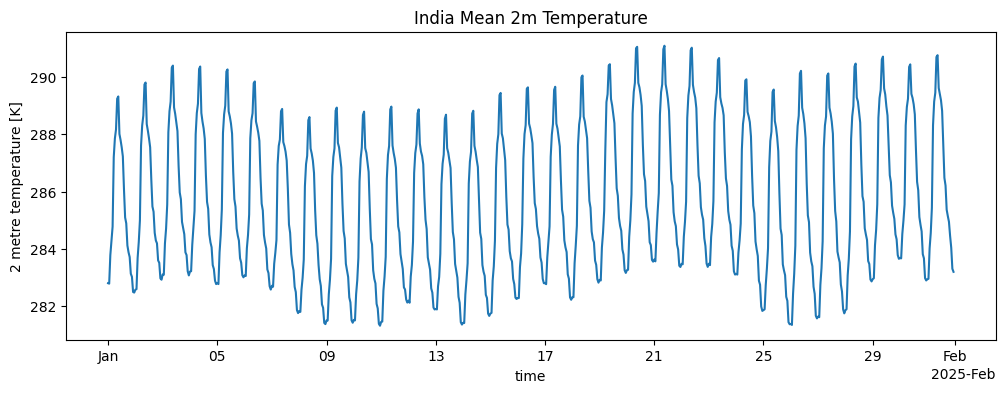

In [4]:
jan2025 = india.sel(
    time=slice("2025-01-01","2025-01-31")
)

ts = jan2025.mean(["latitude","longitude"])

ts.plot(figsize=(12,4))
plt.title("India Mean 2m Temperature")

Text(0.5, 1.0, 'January Mean Temperature')

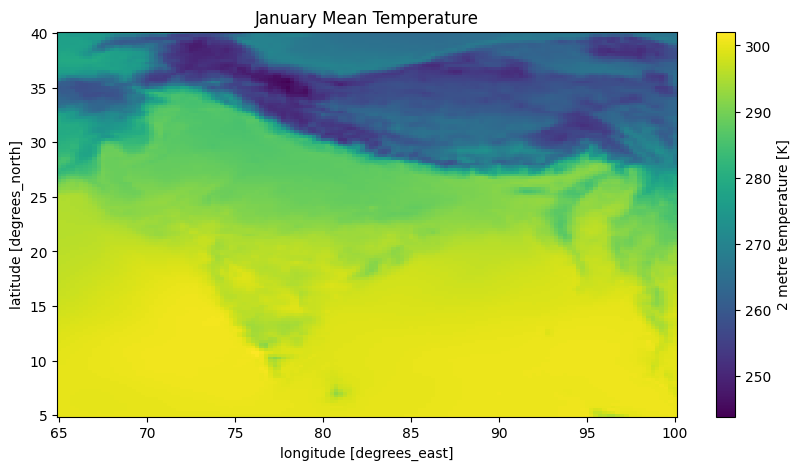

In [5]:
mean_map = jan2025.mean("time")

mean_map.plot(figsize=(10,5))
plt.title("January Mean Temperature")

Text(0.5, 1.0, 'Temperature Variability')

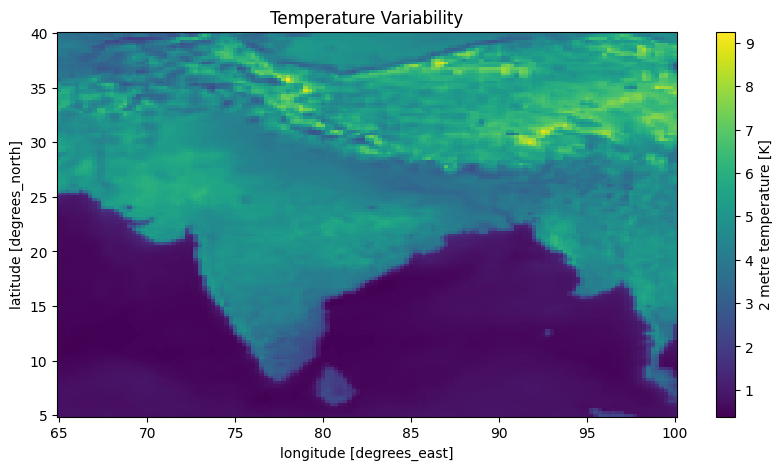

In [6]:
std_map = jan2025.std("time")

std_map.plot(figsize=(10,5))
plt.title("Temperature Variability")

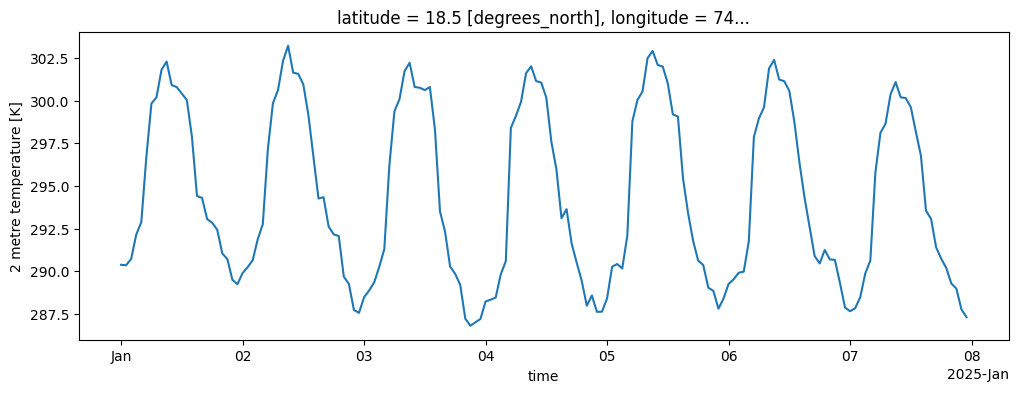

In [7]:
pune = india.sel(
    latitude=18.5,
    longitude=73.9,
    method="nearest"
)

pune.sel(
    time=slice("2025-01-01","2025-01-07")
).plot(figsize=(12,4))

Text(0.5, 1.0, 'India Seasonal Temperature Cycle')

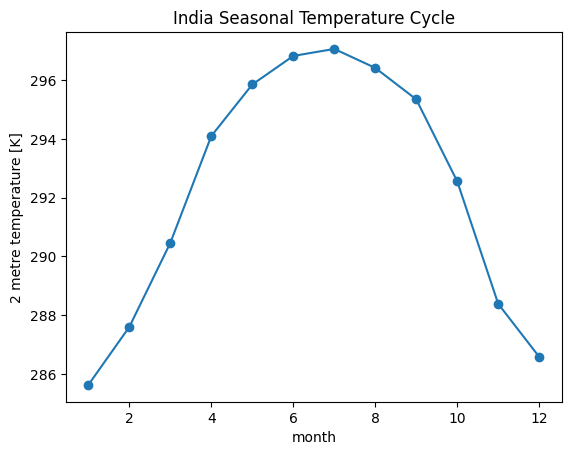

In [8]:
yr = india.sel(
    time=slice("2025-01-01","2025-12-31")
)

monthly = (
    yr.mean(["latitude","longitude"])
      .groupby("time.month")
      .mean()
)

monthly.plot(marker="o")
plt.title("India Seasonal Temperature Cycle")

In [9]:
clim = (
    india.sel(time=slice("2000","2024"))
    .groupby("time.month")
    .mean()
)

In [10]:
daily = (
    india.mean(["latitude","longitude"])
)

anom = daily.groupby("time.dayofyear") - \
       daily.groupby("time.dayofyear").mean()

anom.plot()

KeyboardInterrupt: 

In [11]:
threshold = india.quantile(0.95)

extreme_days = (india > threshold).sum("time")

extreme_days.plot(figsize=(10,5))

KeyboardInterrupt: 